###Librerias


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

In [2]:
#conectamos al drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/PLATZI/Fundamentos de Machine learning/comentarios_deportivos.csv')

In [4]:
df['comentario'] = df['comentario'].astype(str)
df

,id,comentario,sentimiento
0,180,"Partido equilibrado, resultado justo.",Neutral
1,177,"Encuentro equilibrado, reparto justo de puntos.",Neutral
2,189,Resultado esperado dadas las circunstancias.,Neutral
3,132,Nuestro ataque no generó peligro suficiente.,Negativo
4,148,"Sin sobresaltos, rendimiento promedio.",Neutral
...,...,...,...
195,124,Errores constantes en pases y posesión.,Negativo
196,185,Rendimiento estable en defensa y ataque.,Neutral
197,13,Controlamos claramente el ritmo del partido.,Positivo
198,90,El equipo pareció desorganizado en todo momento.,Negativo


In [5]:
!pip install re

ERROR: Could not find a version that satisfies the requirement re (from versions: none)
ERROR: No matching distribution found for re


In [6]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords')
nltk.download('wordnet')

def limpiar_texto_limpio(texto):
  texto = texto.lower()
  texto = re.sub(r"http\S+|www\S+|https\S+", '', texto)
  texto = re.sub(r'\@\w+|\#','', texto)
  return texto

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [7]:
#Aplcamos la limpieza
df['comentario_limpio'] = df['comentario'].apply(limpiar_texto_limpio)

In [8]:
df

,id,comentario,sentimiento,comentario_limpio
0,180,"Partido equilibrado, resultado justo.",Neutral,"partido equilibrado, resultado justo."
1,177,"Encuentro equilibrado, reparto justo de puntos.",Neutral,"encuentro equilibrado, reparto justo de puntos."
2,189,Resultado esperado dadas las circunstancias.,Neutral,resultado esperado dadas las circunstancias.
3,132,Nuestro ataque no generó peligro suficiente.,Negativo,nuestro ataque no generó peligro suficiente.
4,148,"Sin sobresaltos, rendimiento promedio.",Neutral,"sin sobresaltos, rendimiento promedio."
...,...,...,...,...
195,124,Errores constantes en pases y posesión.,Negativo,errores constantes en pases y posesión.
196,185,Rendimiento estable en defensa y ataque.,Neutral,rendimiento estable en defensa y ataque.
197,13,Controlamos claramente el ritmo del partido.,Positivo,controlamos claramente el ritmo del partido.
198,90,El equipo pareció desorganizado en todo momento.,Negativo,el equipo pareció desorganizado en todo momento.


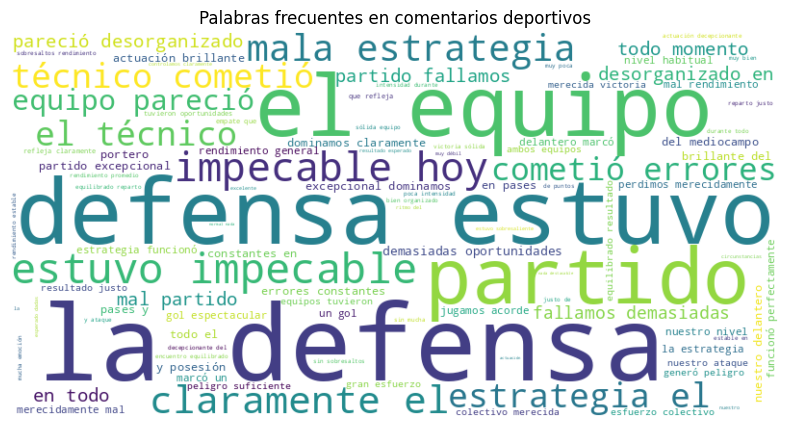

In [9]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Filtrar comentarios útiles
df_filtrado = df[df['comentario_limpio'].str.strip().astype(bool)]

# Unir todos los comentarios limpios
texto_total = ' '.join(df_filtrado['comentario_limpio'])

# Generar nube
if texto_total:
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(texto_total)
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title("Palabras frecuentes en comentarios deportivos")
    plt.show()
else:
    print("⚠️ No hay palabras útiles después del preprocesamiento.")

/tmp/ipykernel_5129/2183315899.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentimiento', data=df, palette='viridis')


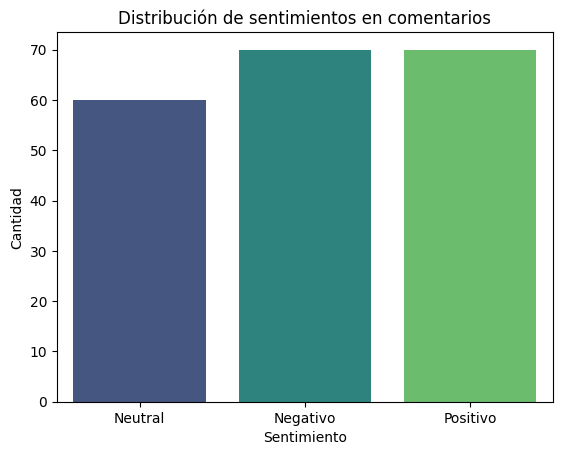

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Verificar columna
if 'sentimiento' in df.columns:
    sns.countplot(x='sentimiento', data=df, palette='viridis')
    plt.title('Distribución de sentimientos en comentarios')
    plt.xlabel('Sentimiento')
    plt.ylabel('Cantidad')
    plt.show()
else:
    print("⚠️ No se encontró la columna 'sentimiento'.")

In [11]:
import ipywidgets as widgets
from IPython.display import display

sentimiento_widget = widgets.Dropdown(options=df['sentimiento'].unique(), description='Sentimiento:')

def mostrar_comentarios(sentimiento):
    seleccionados = df[df['sentimiento'] == sentimiento]
    display(seleccionados[['comentario', 'comentario_limpio']].sample(5))

widgets.interactive(mostrar_comentarios, sentimiento=sentimiento_widget)

interactive(children=(Dropdown(description='Sentimiento:', options=('Neutral', 'Negativo', 'Positivo'), value=…